Projeto final - Módulo 1 - SCTEC

# Fase 3: Feature Engineering

Crie uma nova coluna numérica por meio de operação matemática entre colunas existentes, tratando os valores nulos previamente.

Sugestão (Manutenção): potencia = velocidade_rotacao_rpm * torque_nm

(É permitida a criação de outra combinação matemática, desde que explicada no vídeo e documentada no notebook).

In [1]:
# Configuração inicial para todos os notebooks

# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração do visual global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("n\=== CONFIGURAÇÕES E BIBLIOTECAS IMPORTADAS COM SUCESSO ===")


<>:16: SyntaxWarning: "\=" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\="? A raw string is also an option.
<>:16: SyntaxWarning: "\=" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\="? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_21148\1905118335.py:16: SyntaxWarning: "\=" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\="? A raw string is also an option.
  print("n\=== CONFIGURAÇÕES E BIBLIOTECAS IMPORTADAS COM SUCESSO ===")


n\=== CONFIGURAÇÕES E BIBLIOTECAS IMPORTADAS COM SUCESSO ===


In [2]:
# Carregando os dados do dataset tratado

df_tratado = pd.read_csv("../data/processed/manutencao_preditiva_tratado.csv", sep=",")
df_tratado.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,300.1,310.1,1504.0,40.1,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [3]:
# Removendo as colunas que não serão usados

df_fe = df_tratado.drop(
    columns=[
        "udi",
        "falha_twf",
        "falha_hdf",
        "falha_pwf",
        "falha_osf",
        "falha_rnf"
    ]
)
df_fe.head()

,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina
0,M14860,M,298.1,308.6,1551.0,42.8,0,0
1,L47181,L,298.2,308.7,1408.0,46.3,3,0
2,L47182,L,298.1,308.5,1498.0,49.4,5,0
3,L47183,L,300.1,310.1,1504.0,40.1,7,0
4,L47184,L,298.2,308.7,1408.0,40.0,9,0


In [4]:
# Criando uma nova coluna 

# potencia = velocidade_rotacao_rpm * torque_nm, conforme sugerido, sem a preocupação com a unidade física exata da potência.

df_fe["potencia_calc"] = (df_fe["velocidade_rotacao_rpm"] * df_fe["torque_nm"])
df_fe.head()


,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,potencia_calc
0,M14860,M,298.1,308.6,1551.0,42.8,0,0,66382.8
1,L47181,L,298.2,308.7,1408.0,46.3,3,0,65190.4
2,L47182,L,298.1,308.5,1498.0,49.4,5,0,74001.2
3,L47183,L,300.1,310.1,1504.0,40.1,7,0,60310.4
4,L47184,L,298.2,308.7,1408.0,40.0,9,0,56320.0


In [5]:
# Analisando os dados desta nova coluna

df_fe["potencia_calc"].describe()

count    10000.000000
mean     59970.673120
std       9951.344325
min      10966.800000
25%      53497.050000
50%      60310.400000
75%      66412.975000
max      99980.400000
Name: potencia_calc, dtype: float64

Grafico salvo em:../outputs/graficos\03_fe\01_histograma_potencia.png


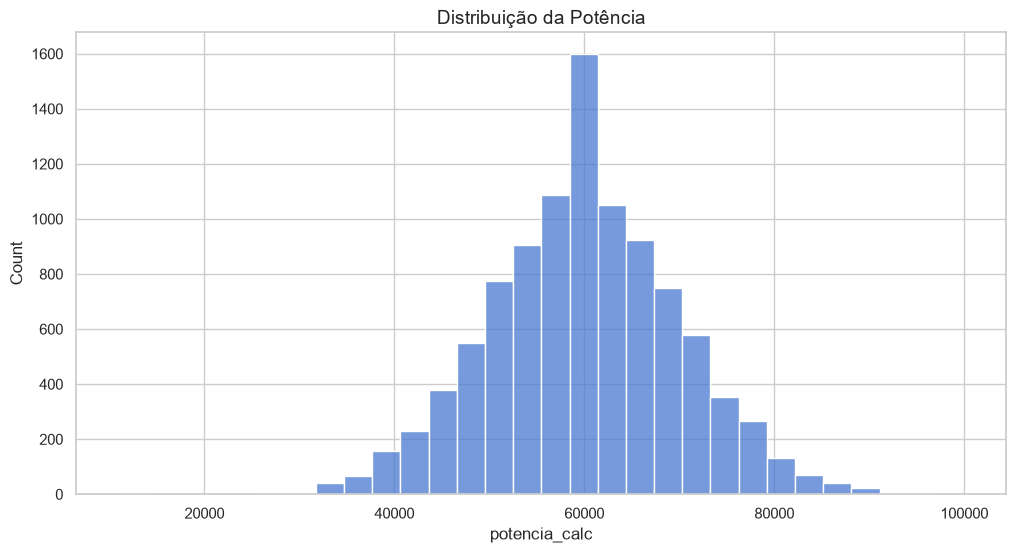

In [6]:
# Histograma da potência

# Para os gráficos serem salvos na pasta "outputs"

def salvar_grafico(nome_arquivo, etapa="03_fe", output_base_dir="../outputs/graficos"): # cria a subpasta para a etapa atual e exporta o gráfico gerado
    output_dir = os.path.join(output_base_dir, etapa)
    os.makedirs(output_dir, exist_ok=True) # cria o caminho dinâmico

    caminho_completo = os.path.join(output_dir, f"{nome_arquivo}.png") # define o caminho final do arquivo de imagem

    plt.savefig(caminho_completo, dpi=300, bbox_inches="tight")
    print(f"Grafico salvo em:{caminho_completo}") #salva o gráfico atual

sns.histplot(df_fe["potencia_calc"], bins=30)
plt.title("Distribuição da Potência")
salvar_grafico("01_histograma_potencia")
plt.show()

Grafico salvo em:../outputs/graficos\03_fe\02_boxplot_potencia.png


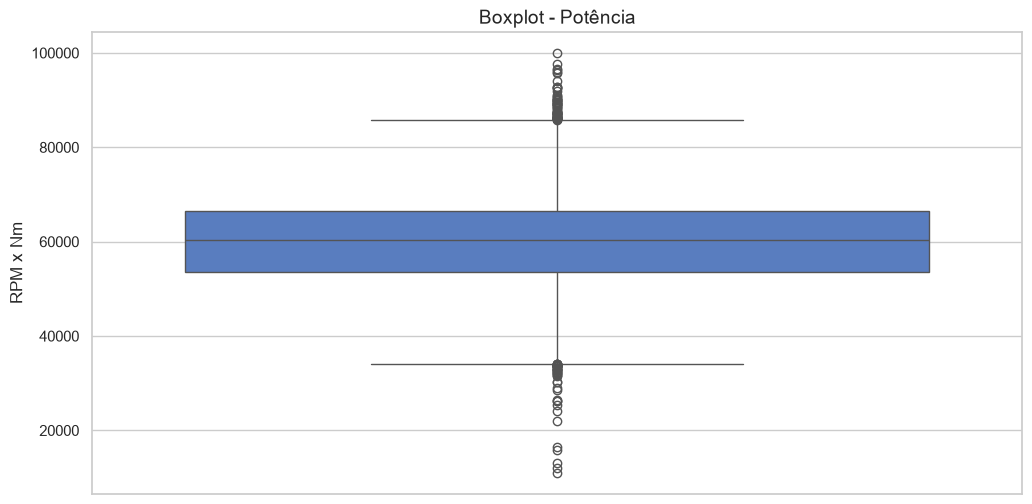

In [7]:
# Boxplot da potência

sns.boxplot(data=df_fe["potencia_calc"])
plt.title ("Boxplot - Potência")
plt.ylabel("RPM x Nm")
salvar_grafico("02_boxplot_potencia")
plt.show()

Análise

Analisando os gráficos da potência calculada, pelo histograma observa-se que os dados possuem uma distribuição bastante simétrica e com formato de uma curva normal. Esta distribuição sugere que a variável criada preservou um comportamento consistente e pode fornecer informações relevantes para a etapa de modelagem preditiva. A maior concentração dos valores está em torno de 60.000 RPM x Nm, indicando que a maior parte das máquinas opera dentro desta faixa. Já no boxplot, observa-se uma distribuição relativamente equilibrada dos dados, concentrados em torno da mediana. Também são observados outliers, tanto acima quanto abaixo dos limites. Os outliers foram mantidos para o aprendizado do modelo.